<a href="https://colab.research.google.com/github/em2tech/Machine_Learning_SJU/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_auc_score, roc_curve, accuracy_score, f1_score)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

In [4]:
CSV_NAME = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

if os.path.exists(CSV_NAME):
    csv_path = CSV_NAME
else:
    try:
        import kagglehub
        dataset_dir = kagglehub.dataset_download('blastchar/telco-customer-churn')
        csv_path = os.path.join(dataset_dir, CSV_NAME)
    except Exception as e:
        print('kagglehub download failed, falling back to manual upload:', e)
        from google.colab import files
        uploaded = files.upload()          # choose the CSV downloaded from Kaggle
        csv_path = list(uploaded.keys())[0]

df = pd.read_csv(csv_path)
print('Shape:', df.shape)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Shape: (7043, 21)


In [5]:
display(df.head())

print('\n--- info() ---')
df.info()

print('\n--- describe() : numeric columns ---')
display(df.describe())

print('--- describe() : categorical / object columns ---')
display(df.describe(exclude='number'))

key_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod']
print('Data types of key features:')
print(df[key_cols].dtypes, '\n')

for col in ['Contract', 'PaymentMethod', 'Churn']:
    print(f'{col} value counts:')
    print(df[col].value_counts(), '\n')

print('Churn rate: {:.1%}'.format((df['Churn'] == 'Yes').mean()))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


--- describe() : categorical / object columns ---


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


Data types of key features:
tenure              int64
MonthlyCharges    float64
TotalCharges       object
Contract           object
PaymentMethod      object
dtype: object 

Contract value counts:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64 

PaymentMethod value counts:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64 

Churn value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64 

Churn rate: 26.5%


In [6]:
print('Unique customerIDs:', df['customerID'].nunique(), 'of', len(df), 'rows')
df = df.drop(columns=['customerID'])
print('Remaining columns:', df.shape[1])

Unique customerIDs: 7043 of 7043 rows
Remaining columns: 20


In [7]:
print('Explicit NaN values per column:')
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().any() else 'None found', '\n')

obj_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
blank_counts = {c: df[c].astype(str).str.strip().eq('').sum() for c in obj_cols}
blank_counts = {c: int(n) for c, n in blank_counts.items() if n > 0}
print('Implicit missing values (blank / whitespace strings):', blank_counts)

# Replace whitespace-only strings with NaN, then convert TotalCharges to numeric
df = df.replace(r'^\s*$', np.nan, regex=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('\nMissing values after conversion:')
print(df.isna().sum()[df.isna().sum() > 0])

# Look at the rows with missing TotalCharges
print('\nTenure of customers with missing TotalCharges:')
print(df.loc[df['TotalCharges'].isna(), 'tenure'].value_counts())

# Encode the target: Yes -> 1 (churned), No -> 0 (stayed)
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Demonstrate the imputation strategy (the pipeline repeats this on training data only)
demo_imputer = SimpleImputer(strategy='median')
imputed_tc = demo_imputer.fit_transform(X[['TotalCharges']])
print('\nMedian used to fill TotalCharges (full-data demo):', round(demo_imputer.statistics_[0], 2))
print('Remaining NaNs after imputation demo:', int(np.isnan(imputed_tc).sum()))

Explicit NaN values per column:
None found 

Implicit missing values (blank / whitespace strings): {'TotalCharges': 11}

Missing values after conversion:
TotalCharges    11
dtype: int64

Tenure of customers with missing TotalCharges:
tenure
0    11
Name: count, dtype: int64

Median used to fill TotalCharges (full-data demo): 1397.48
Remaining NaNs after imputation demo: 0


In [8]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [c for c in X.columns if c not in numeric_features]
print('Numerical features  :', numeric_features)
print('Categorical features:', categorical_features)

def build_preprocessor(scaler='standard'):
    scaler_obj = StandardScaler() if scaler == 'standard' else MinMaxScaler()
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler_obj),
    ])
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])
    return ColumnTransformer([
        ('num', numeric_pipe, numeric_features),
        ('cat', categorical_pipe, categorical_features),
    ])

preprocessor = build_preprocessor('standard')
preprocessor

Numerical features  : ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

In [9]:
def build_model(scaler='standard'):
    return Pipeline([
        ('preprocessor', build_preprocessor(scaler)),
        ('classifier', SGDClassifier(loss='log_loss', penalty='l2', alpha=1e-3,
                                     max_iter=1000, tol=1e-3,
                                     random_state=RANDOM_STATE)),
    ])

model = build_model('standard')
model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 SGDClassifier(alpha=0.001, loss='log_loss', random_state=42))])

===== Split 80/20 (StandardScaler) =====
              precision    recall  f1-score   support

      Stayed       0.85      0.88      0.87      1035
     Churned       0.64      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.79      0.80      0.80      1409

===== Split 70/30 (StandardScaler) =====
              precision    recall  f1-score   support

      Stayed       0.86      0.86      0.86      1552
     Churned       0.61      0.62      0.61       561

    accuracy                           0.79      2113
   macro avg       0.73      0.74      0.74      2113
weighted avg       0.79      0.79      0.79      2113

===== Split 60/40 (StandardScaler) =====
              precision    recall  f1-score   support

      Stayed       0.87      0.85      0.86      2070
     Churned       0.61      0.63      0.62       748

    accuracy                           0.80      2818
   ma

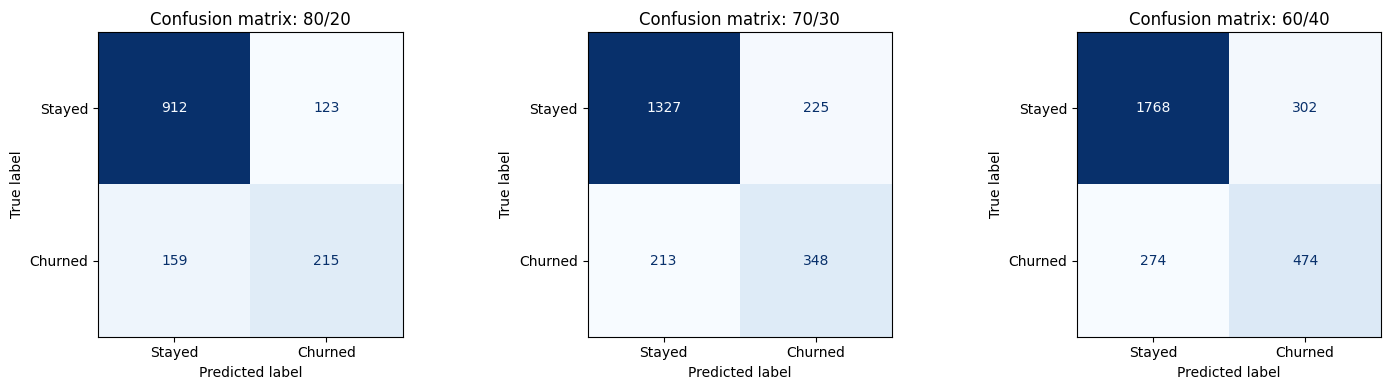

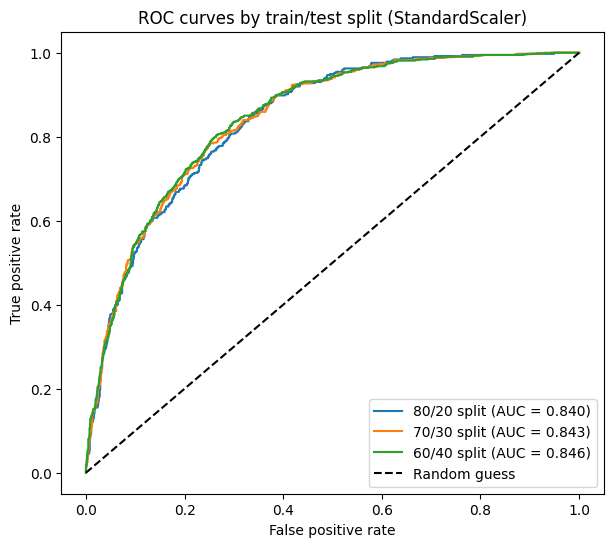

Performance summary across splits and scalers:


,split,scaler,train_rows,test_rows,accuracy,f1_churn,roc_auc,epochs_to_converge
0,80/20,standard,5634,1409,0.7999,0.6039,0.8404,27
1,80/20,minmax,5634,1409,0.7963,0.5952,0.8376,27
2,70/30,standard,4930,2113,0.7927,0.6138,0.8435,32
3,70/30,minmax,4930,2113,0.7979,0.5717,0.8413,21
4,60/40,standard,4225,2818,0.7956,0.6220,0.8456,28
5,60/40,minmax,4225,2818,0.7956,0.6155,0.8431,28


In [10]:
split_ratios = [0.20, 0.30, 0.40]
results, roc_data, fitted_models = [], {}, {}

fig_cm, axes_cm = plt.subplots(1, len(split_ratios), figsize=(15, 4))

for i, test_size in enumerate(split_ratios):
    label = f'{int((1 - test_size) * 100)}/{int(test_size * 100)}'
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=RANDOM_STATE)

    for scaler in ['standard', 'minmax']:
        clf = build_model(scaler).fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)

        results.append({
            'split': label, 'scaler': scaler,
            'train_rows': len(X_train), 'test_rows': len(X_test),
            'accuracy': accuracy_score(y_test, y_pred),
            'f1_churn': f1_score(y_test, y_pred),
            'roc_auc': auc,
            'epochs_to_converge': clf.named_steps['classifier'].n_iter_,
        })

        if scaler == 'standard':
            fitted_models[label] = clf
            roc_data[label] = roc_curve(y_test, y_proba) + (auc,)
            print(f'===== Split {label} (StandardScaler) =====')
            print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))
            ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                                   display_labels=['Stayed', 'Churned']).plot(
                ax=axes_cm[i], cmap='Blues', colorbar=False)
            axes_cm[i].set_title(f'Confusion matrix: {label}')

plt.tight_layout()
plt.show()

# ROC curves for all three splits
plt.figure(figsize=(7, 6))
for label, (fpr, tpr, _, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{label} split (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curves by train/test split (StandardScaler)')
plt.legend()
plt.show()

results_df = pd.DataFrame(results)
print('Performance summary across splits and scalers:')
display(results_df.round(4))

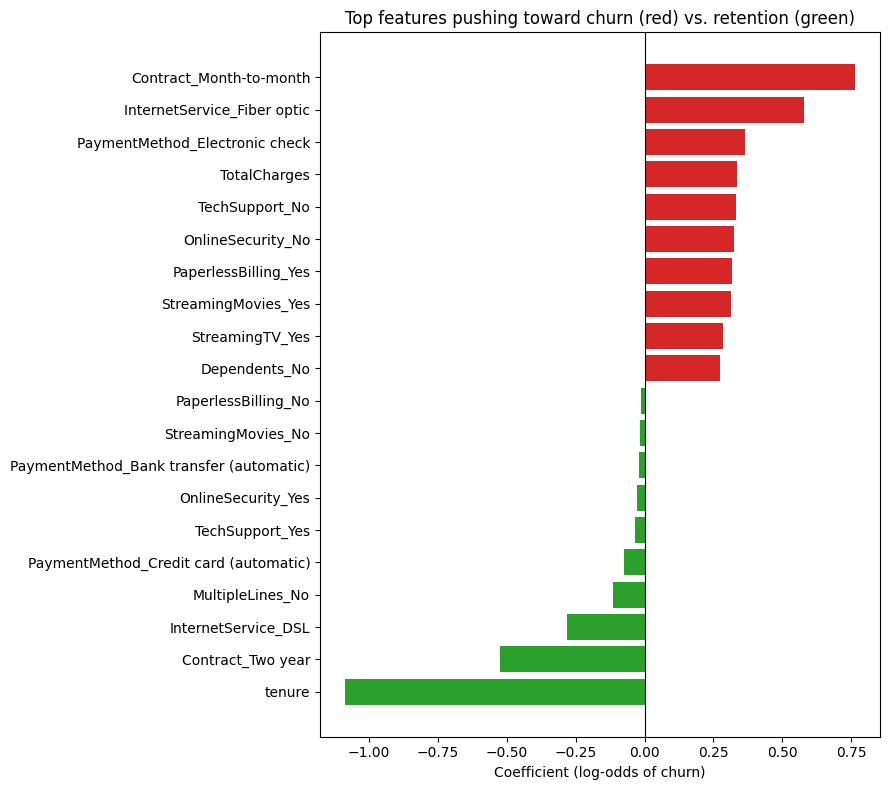

Top 10 features increasing churn risk:


,feature,coefficient
0,Contract_Month-to-month,0.761651
1,InternetService_Fiber optic,0.579687
2,PaymentMethod_Electronic check,0.364911
3,TotalCharges,0.334138
4,TechSupport_No,0.332746
5,OnlineSecurity_No,0.323427
6,PaperlessBilling_Yes,0.317290
7,StreamingMovies_Yes,0.311954
8,StreamingTV_Yes,0.286096
9,Dependents_No,0.274337


Top 10 features decreasing churn risk:


,feature,coefficient
0,tenure,-1.084718
1,Contract_Two year,-0.525160
2,InternetService_DSL,-0.282918
3,MultipleLines_No,-0.115595
4,PaymentMethod_Credit card (automatic),-0.074232
5,TechSupport_Yes,-0.035976
6,OnlineSecurity_Yes,-0.026657
7,PaymentMethod_Bank transfer (automatic),-0.021783
8,StreamingMovies_No,-0.015185
9,PaperlessBilling_No,-0.013463


In [11]:
best = fitted_models['80/20']
feature_names = best.named_steps['preprocessor'].get_feature_names_out()
coefs = best.named_steps['classifier'].coef_[0]

coef_df = (pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
             .assign(feature=lambda d: d['feature'].str.replace(r'^(num|cat)__', '', regex=True))
             .sort_values('coefficient'))

top = pd.concat([coef_df.head(10), coef_df.tail(10)])
colors = ['tab:green' if c < 0 else 'tab:red' for c in top['coefficient']]

plt.figure(figsize=(9, 8))
plt.barh(top['feature'], top['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top features pushing toward churn (red) vs. retention (green)')
plt.xlabel('Coefficient (log-odds of churn)')
plt.tight_layout()
plt.show()

print('Top 10 features increasing churn risk:')
display(coef_df.tail(10).iloc[::-1].reset_index(drop=True))
print('Top 10 features decreasing churn risk:')
display(coef_df.head(10).reset_index(drop=True))